# HFR calibration — dynamic model
Calibrate the undetermined ohmic-resistance parameters of the 1D dynamic PEMFC model (`PEMFC_dyn`) by fitting the simulated HFR — `sum(Rmem) + Re` at the final integration step — to the experimental HFR. Compare the calibration outcome across four experimental subsets (one condition / fixed pressure / fixed temperature / all data).

In [1]:
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import optuna
from optuna.pruners import MedianPruner
from copy import deepcopy
from scipy.integrate import solve_ivp
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")


In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from config.settings import *
from model.dynamic import PEMFC_dyn
from model.coefficients import *
from config.initialize import *


## Calibration setup

In [3]:
# Tested currents and the (T, P, RHC) grid we sweep over.
I_tested   = [10, 20, 30, 40, 50]
RHC_tested = [0, 50]
PAC_tested = [1.3e5, 1.4e5, 1.5e5]
TFC_tested = [50, 60, 70]


### Experiment data import

In [4]:
# Load the HFR experimental data. Each sheet name is "T{C}_P{mbar_gauge}_HRC{%}".
# The R column stores a "(R, I)" tuple as a string -- pull out the float R.
hfr_data_path = project_root / "data" / "HFR.xlsx"
hfr_testdata  = pd.read_excel(hfr_data_path, sheet_name=None)
hfrdata_exp   = {}
for sheet_name, raw in hfr_testdata.items():
    parsed = raw["R"].str.strip("()").str.split(",", expand=True).astype(float)
    hfrdata_exp[sheet_name] = pd.DataFrame({"I_LOAD": raw["I_LOAD"], "R": parsed[0]})
print(f"Loaded {len(hfrdata_exp)} HFR sheets: {list(hfrdata_exp.keys())}")


Loaded 12 HFR sheets: ['T50_P300_HRC0', 'T50_P300_HRC50', 'T50_P400_HRC50', 'T50_P500_HRC50', 'T60_P300_HRC0', 'T60_P300_HRC50', 'T60_P400_HRC50', 'T60_P500_HRC50', 'T70_P300_HRC0', 'T70_P300_HRC50', 'T70_P400_HRC50', 'T70_P500_HRC50']


### Define `hfrtest_sim` and the objective factory

In [5]:
def hfrtest_sim(model_calib, cond_filter=None):
    """Run the dynamic model across every (RHC, P, T) condition for which we
    have experimental HFR data and return ``{cond_key: [HFR at I_tested]}``
    in Ohm.m^2 per cell (HFR = sum(Rmem) + Re at the final integration step).
    Returns ``False`` if any HFR was non-finite.

    Pass ``cond_filter(T, P, RHC) -> bool`` to restrict which conditions
    are simulated.
    """
    Aact = model_calib.parameters["Aact"]
    Re   = model_calib.parameters["Re"]
    op   = model_calib.operating_inputs

    result = {}
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des/1e2 - 1e3)) + "_HRC" + str(RHC)
                if cond_key not in hfrdata_exp:
                    continue
                if cond_filter is not None and not cond_filter(T_des, P_des, RHC):
                    continue
                op["Phi_a_des"] = RHC / 100
                op["Phi_c_des"] = RHC / 100
                op["Pa_des"]    = P_des
                op["Pc_des"]    = P_des
                op["Tfc"]       = T_des + 273.15

                hfr_test = []
                for I_LOAD in I_tested:
                    i_density = I_LOAD / Aact
                    op["current_density"] = lambda t, _i=i_density: _i
                    x_init = init_x(op, model_calib.parameters)
                    sol = solve_ivp(model_calib.dxdt, (0, 60), x_init,
                                    method="BDF", max_step=1e-1)
                    last = {k: sol.y[idx, -1] for idx, k in enumerate(model_calib.solver_variable_names)}
                    Rmem_t, _, _ = Rproton(last, model_calib.parameters)
                    hfr_predicted = float(sum(Rmem_t)) + Re
                    if not math.isfinite(hfr_predicted):
                        return False
                    hfr_test.append(hfr_predicted)
                result[cond_key] = hfr_test
    return result


In [6]:
def _experimental_hfr(cond_key):
    """Look up the experimental HFR at every I_tested for one condition.
    The Excel sheets store R as a "(R, I)" string in mOhm at the stack level;
    convert to Ohm.m^2 per cell:  R[mOhm] * 1e-3 / n_cell * Aact.
    """
    df = hfrdata_exp[cond_key]
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    r_exp = df["R"].to_numpy(dtype=float) * 1e-3 / n_cell * parameters["Aact"]
    idx = [np.argmin((i_test - i_exp) ** 2) for i_test in I_tested]
    return r_exp[idx]


def make_objective(cond_filter):
    """Return an optuna objective that fits only the conditions selected by
    ``cond_filter`` -- so a single objective function can be reused across
    the four calibration scenarios."""
    def objective(trial):
        params_trial = deepcopy(parameters)
        op_trial     = deepcopy(operating_inputs)

        params_trial["Re"]          = trial.suggest_float("Re",          1e-7, 5e-6, log=True)
        params_trial["epsilon_gdl"] = trial.suggest_float("epsilon_gdl", 0.5,  0.8)
        params_trial["epsilon_mc"]  = trial.suggest_float("epsilon_mc",  0.15, 0.4)
        params_trial["epsilon_cl"]  = trial.suggest_float("epsilon_cl",  0.1,  0.4)
        params_trial["epsilon_c"]   = trial.suggest_float("epsilon_c",   0.2,  0.3)
        params_trial["tau"]         = trial.suggest_float("tau",         1.0,  4.0)
        params_trial["Hgdl"]        = trial.suggest_float("Hgdl",        2e-5, 5e-5, log=True)
        params_trial["Hcl"]         = trial.suggest_float("Hcl",         1e-5, 2e-5, log=True)

        model_trial = PEMFC_dyn(params_trial, op_trial,
                                init_x(op_trial, params_trial))
        try:
            sim = hfrtest_sim(model_trial, cond_filter=cond_filter)
        except Exception:
            return 1e6
        if sim is False or not sim:
            return 1e6

        error = 0.0
        for cond_key, r_sim in sim.items():
            r_exp = _experimental_hfr(cond_key)
            error += float(np.sum((np.array(r_sim) - r_exp) ** 2))
        return error
    return objective


## Calibration scenarios

In [ ]:
# Anchor conditions for the partial calibration scenarios -- edit if you
# want different subsets. Defaults are picked so each scenario maps to at
# least one condition present in the experimental dataset.
SINGLE_T   = 60       # degrees C
SINGLE_P   = 1.4e5    # Pa
SINGLE_RHC = 50       # %         (RHC=0 is only available at P=1.3 bar)
TWO_HUM_T  = 50       # degrees C -- scenario "two humidifications"
TWO_HUM_P  = 1.3e5    # Pa        -- (RHC=0 and RHC=50 are both available at P=1.3 bar)
FIXED_P    = 1.3e5    # Pa  -- scenario "fixed pressure"
FIXED_T    = 60       # degrees C -- scenario "fixed temperature"

scenarios = {
    "one_condition":      {
        "label":  f"One condition (T={SINGLE_T}, P={SINGLE_P/1e5:.1f} bar, RHC={SINGLE_RHC})",
        "filter": lambda T, P, RHC: (T == SINGLE_T) and (P == SINGLE_P) and (RHC == SINGLE_RHC),
    },
    "two_humidification": {
        "label":  f"Two humidifications (P={TWO_HUM_P/1e5:.1f} bar, T={TWO_HUM_T}, RHC in {{0, 50}})",
        "filter": lambda T, P, RHC: (T == TWO_HUM_T) and (P == TWO_HUM_P) and (RHC in (0, 50)),
    },
    "fixed_pressure":     {
        "label":  f"Fixed pressure (P={FIXED_P/1e5:.1f} bar, all T, all RHC)",
        "filter": lambda T, P, RHC: P == FIXED_P,
    },
    "fixed_temperature":  {
        "label":  f"Fixed temperature (T={FIXED_T}, all P, all RHC)",
        "filter": lambda T, P, RHC: T == FIXED_T,
    },
    "all_data":           {
        "label":  "All conditions",
        "filter": lambda T, P, RHC: True,
    },
}


def conditions_in_scenario(filter_fn):
    """Return the cond_keys present in the experimental data that pass the filter."""
    keys = []
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des/1e2 - 1e3)) + "_HRC" + str(RHC)
                # Look up against whichever experimental-data dict this notebook uses.
                exp_data = globals().get("polardata_exp") or globals().get("hfrdata_exp") or {}
                if cond_key in exp_data and filter_fn(T_des, P_des, RHC):
                    keys.append(cond_key)
    return keys


for name, info in scenarios.items():
    matches = conditions_in_scenario(info["filter"])
    print(f"  {name:20s}  {len(matches):2d} conditions  -> {matches}")


In [8]:
# Run a separate optuna study per scenario. Each dynamic trial does
# len(I_tested) short BDF integrations per condition, so the budget grows
# with the size of the calibration subset. Total wall time ~
# (timeout per scenario) * 4.
optuna.logging.set_verbosity(optuna.logging.WARNING)

PER_SCENARIO_TIMEOUT = 600     # seconds
PER_SCENARIO_TRIALS  = 2000
N_JOBS               = 6

results = {}
for name, info in scenarios.items():
    print(f"\n=== Calibrating scenario: {name} ===")
    print(f"    {info['label']}")
    print(f"    conditions used: {conditions_in_scenario(info['filter'])}")
    study = optuna.create_study(direction="minimize")
    study.optimize(
        make_objective(info["filter"]),
        n_trials=PER_SCENARIO_TRIALS,
        timeout=PER_SCENARIO_TIMEOUT,
        n_jobs=N_JOBS,
        show_progress_bar=False,
    )

    params_best = deepcopy(parameters)
    op_best     = deepcopy(operating_inputs)
    params_best.update(study.best_params)
    model_best  = PEMFC_dyn(params_best, op_best, init_x(op_best, params_best))
    sim_all     = hfrtest_sim(model_best, cond_filter=None)

    results[name] = {
        "label":           info["label"],
        "calibrated_keys": conditions_in_scenario(info["filter"]),
        "best_params":     study.best_params,
        "best_value":      study.best_value,
        "sim_all":         sim_all if sim_all is not False else {},
    }
    print(f"    best objective on the calibrated subset: {study.best_value:.3e}")



=== Calibrating scenario: one_condition ===
    One condition (T=60, P=1.4 bar, RHC=50)
    conditions used: ['T60_P400_HRC50']
    best objective on the calibrated subset: 2.052e-13

=== Calibrating scenario: fixed_pressure ===
    Fixed pressure (P=1.3 bar, all T, all RHC)
    conditions used: ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50']
    best objective on the calibrated subset: 8.614e-11

=== Calibrating scenario: fixed_temperature ===
    Fixed temperature (T=60, all P, all RHC)
    conditions used: ['T60_P300_HRC0', 'T60_P300_HRC50', 'T60_P400_HRC50', 'T60_P500_HRC50']
    best objective on the calibrated subset: 9.154e-12

=== Calibrating scenario: all_data ===
    All conditions
    conditions used: ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50', 'T50_P400_HRC50', 'T60_P400_HRC50', 'T70_P400_HRC50', 'T50_P500_HRC50', 'T60_P500_HRC50', 'T70_P500_HRC50']
    b

## Best parameters side-by-side

In [9]:
# Side-by-side parameter comparison.
param_df = pd.DataFrame({name: info["best_params"] for name, info in results.items()})
print(param_df.to_string(float_format=lambda v: f"{v:.4g}"))


             one_condition  fixed_pressure  fixed_temperature  all_data
Re               2.239e-06       2.213e-06          1.496e-06  3.25e-06
epsilon_gdl         0.7742          0.5056             0.5002    0.6434
epsilon_mc          0.1787          0.2431             0.2484    0.2714
epsilon_cl          0.1051          0.3631             0.2295    0.2554
epsilon_c           0.2587          0.2809              0.208    0.2321
tau                  3.586           3.955              1.094     2.844
Hgdl             3.837e-05       2.946e-05          2.677e-05 2.998e-05
Hcl              1.503e-05       1.561e-05          1.098e-05 1.866e-05


## Compare best-fit HFR curves across scenarios
`plot_scenario_fit(name)` produces two figures per scenario: the fit on the conditions used during calibration, then the fit on every experimental condition.

In [10]:
import math

def plot_scenario_fit(name):
    """For one calibration scenario, show two figures:
    (1) the HFR fit on the conditions USED in the optimisation,
    (2) the HFR fit on ALL conditions.
    Blue solid markers = experiment, red dotted squares = simulation.
    """
    info = results[name]
    cal_set = set(info["calibrated_keys"])

    panels_to_show = [
        ("USED for calibration", info["calibrated_keys"]),
        ("ALL conditions",       list(hfrdata_exp.keys())),
    ]
    for title_suffix, keys in panels_to_show:
        n = len(keys)
        if n == 0:
            print(f"({name}: no conditions for '{title_suffix}')")
            continue
        ncols = min(4, max(1, n))
        nrows = math.ceil(n / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows),
                                 sharex=True, sharey=True, squeeze=False)
        for ax, cond_key in zip(axes.flatten(), keys):
            r_exp = _experimental_hfr(cond_key)
            r_sim = info["sim_all"].get(cond_key)
            ax.plot(I_tested, r_exp, "o-", color="tab:blue",
                    linewidth=1.4, label="experiment")
            if r_sim is not None:
                ax.plot(I_tested, r_sim, "s:", color="tab:red",
                        linewidth=1.2, label="simulated")
            in_cal = cond_key in cal_set
            tag = "[CAL] " if in_cal else ""
            ax.set_title(f"{tag}{cond_key}", fontsize=8,
                         color="tab:green" if in_cal else "black")
            ax.grid(True, alpha=0.3)
        for ax in axes.flatten()[n:]:
            ax.set_visible(False)
        axes.flatten()[0].legend(fontsize=8, loc="best")
        fig.suptitle(f"{info['label']}  --  {title_suffix}\n"
                     f"objective on calibrated subset = {info['best_value']:.3e}",
                     fontsize=10)
        fig.tight_layout()
        plt.show()


### Scenario: `one_condition`

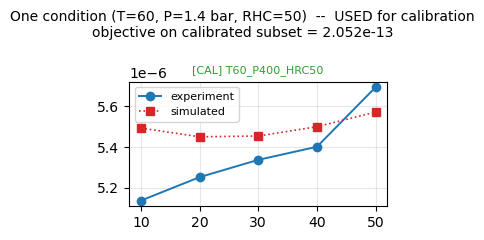

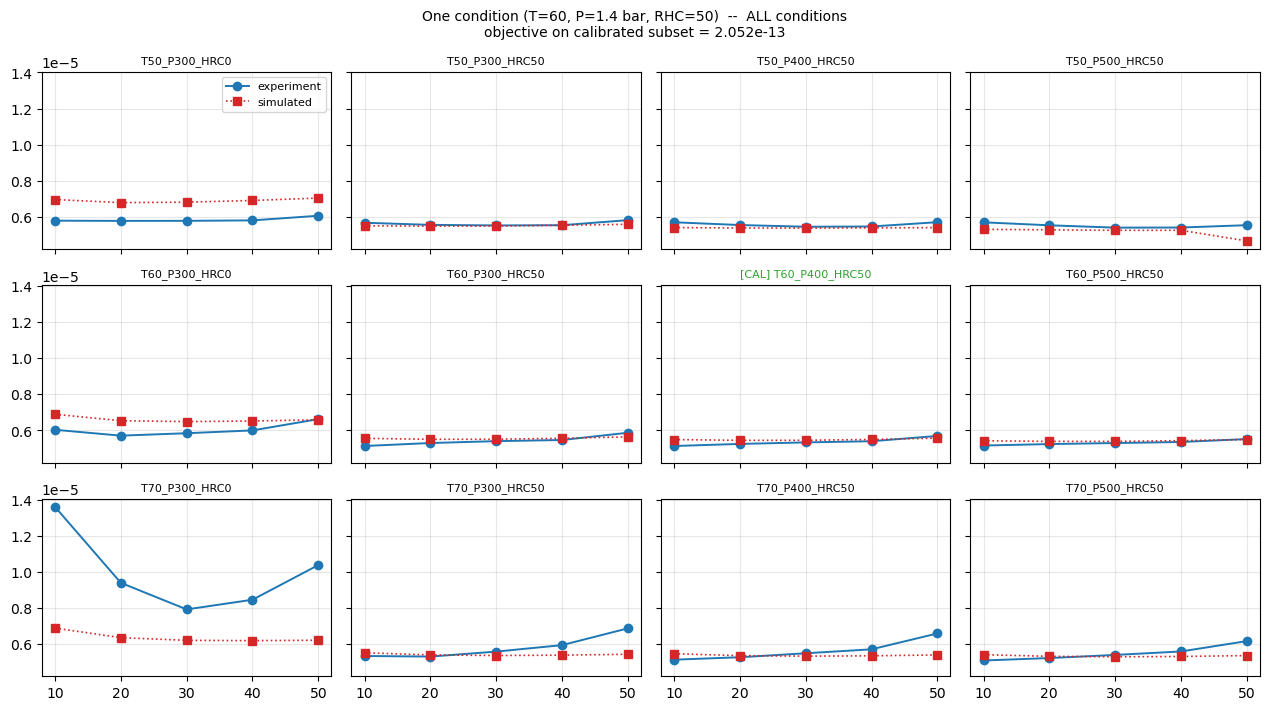

In [11]:
plot_scenario_fit("one_condition")


### Scenario: `two_humidification`
Fit on the two operating conditions that share P and T but differ in cathode humidification (RHC = 0 and 50).


In [ ]:
plot_scenario_fit("two_humidification")


### Scenario: `fixed_pressure`

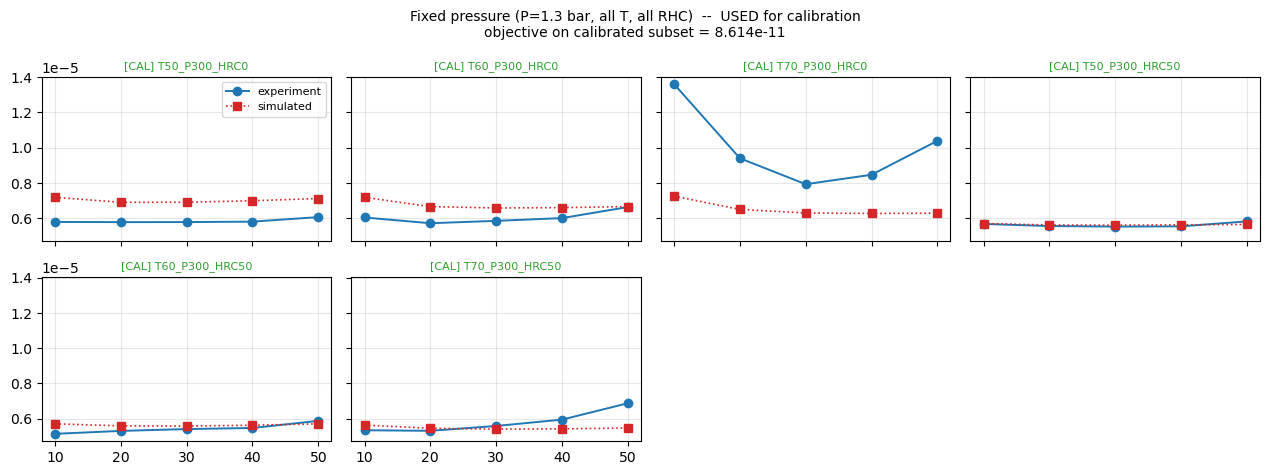

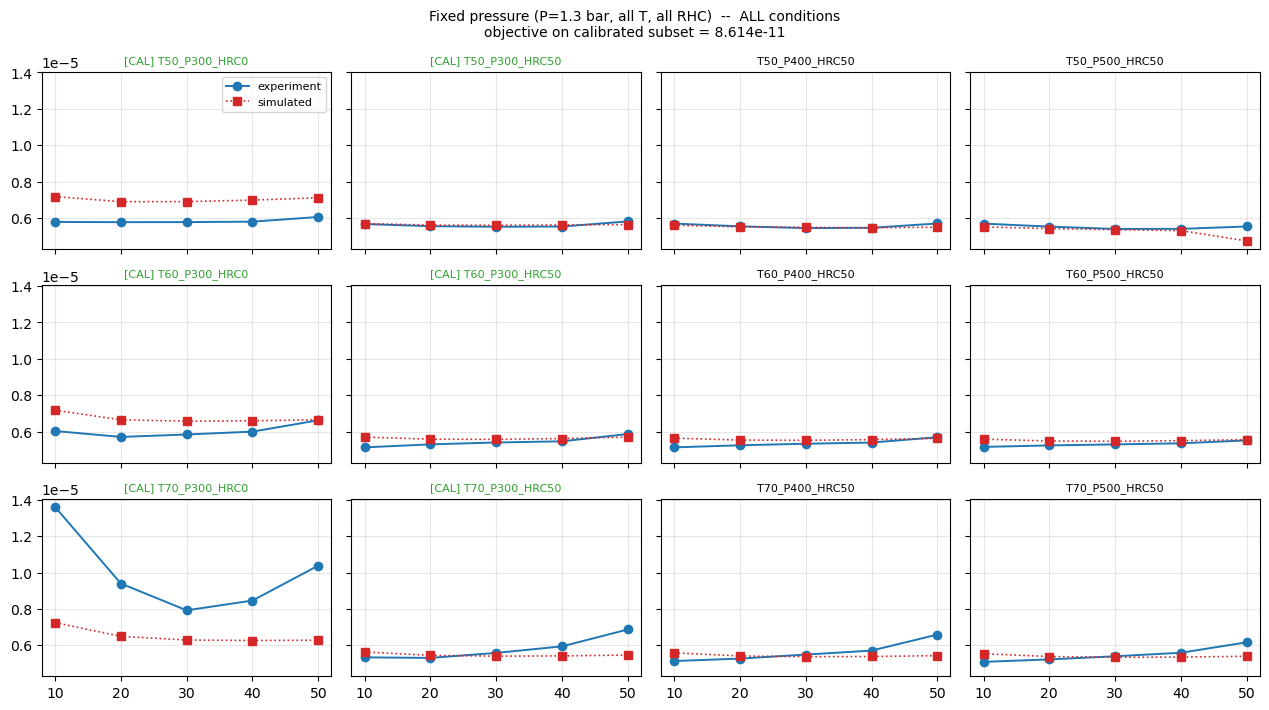

In [12]:
plot_scenario_fit("fixed_pressure")


### Scenario: `fixed_temperature`

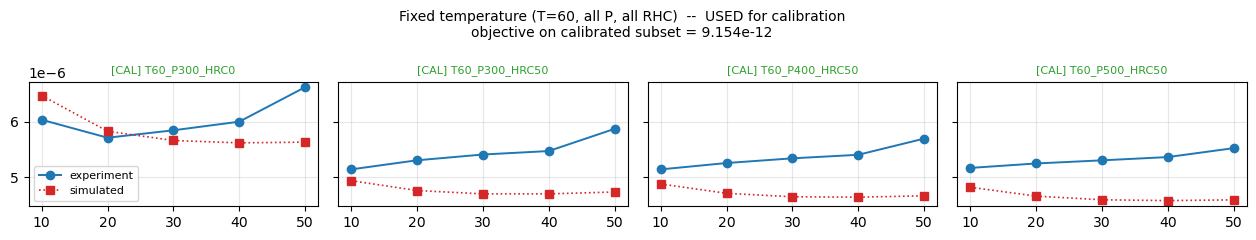

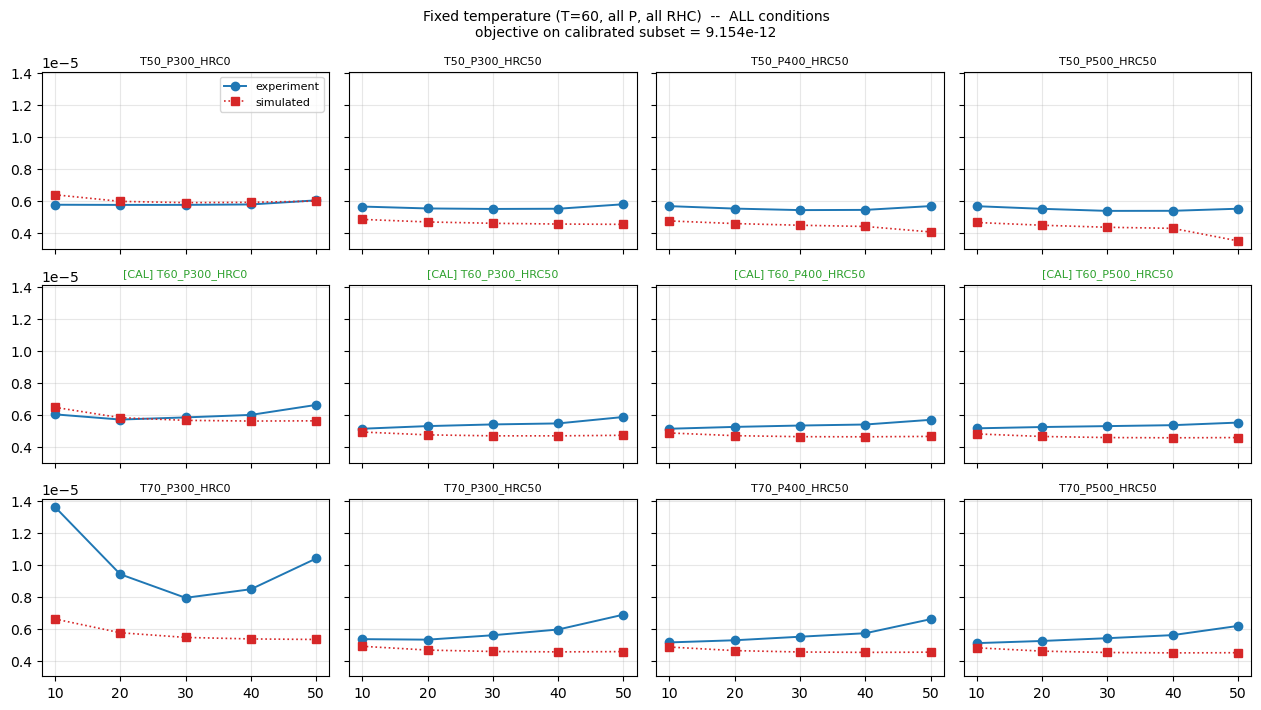

In [13]:
plot_scenario_fit("fixed_temperature")


### Scenario: `all_data`

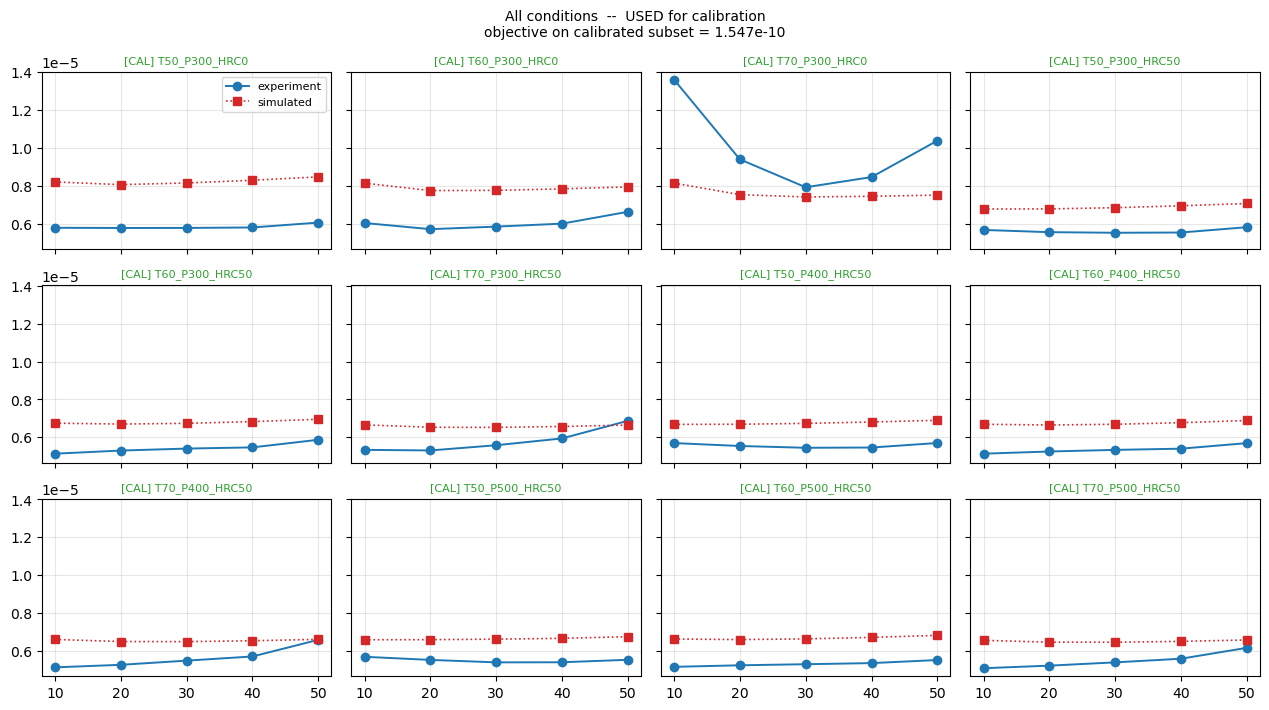

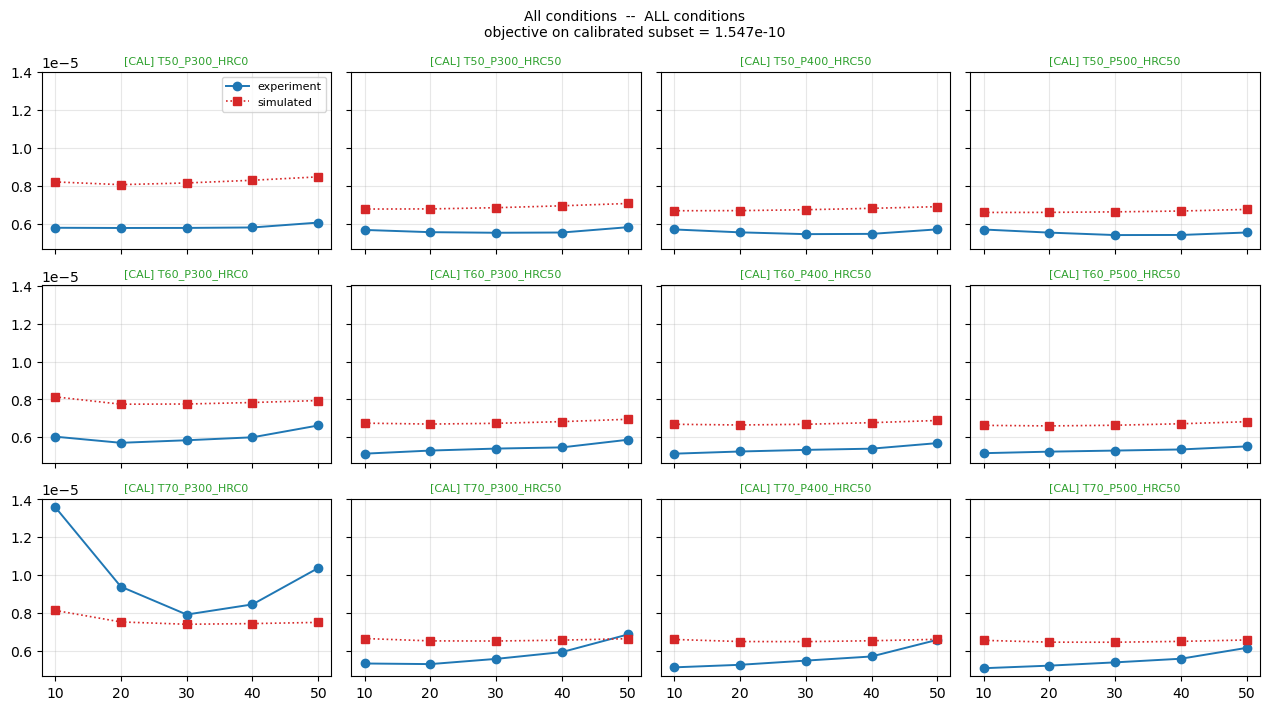

In [14]:
plot_scenario_fit("all_data")


## Residual heatmap

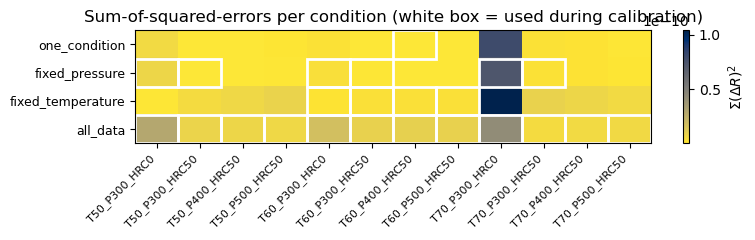

In [15]:
# Residual heatmap: scenarios (rows) x conditions (columns).
all_cond_keys = list(hfrdata_exp.keys())
n_scen = len(results)
residual_matrix = np.full((n_scen, len(all_cond_keys)), np.nan)
for i_scen, (name, info) in enumerate(results.items()):
    for i_cond, cond_key in enumerate(all_cond_keys):
        if cond_key not in info["sim_all"]:
            continue
        r_sim = np.array(info["sim_all"][cond_key])
        r_exp = _experimental_hfr(cond_key)
        residual_matrix[i_scen, i_cond] = float(np.sum((r_sim - r_exp) ** 2))

fig, ax = plt.subplots(figsize=(max(8, len(all_cond_keys) * 0.5), 0.5 + 0.5 * n_scen))
im = ax.imshow(residual_matrix, aspect="auto", cmap="cividis_r")
ax.set_yticks(range(n_scen)); ax.set_yticklabels(list(results.keys()), fontsize=9)
ax.set_xticks(range(len(all_cond_keys)))
ax.set_xticklabels(all_cond_keys, rotation=45, ha="right", fontsize=8)
for i_scen, (name, info) in enumerate(results.items()):
    cal_set = set(info["calibrated_keys"])
    for i_cond, cond_key in enumerate(all_cond_keys):
        if cond_key in cal_set:
            ax.add_patch(plt.Rectangle((i_cond - 0.5, i_scen - 0.5), 1, 1,
                                       fill=False, edgecolor="white", linewidth=2))
ax.set_title("Sum-of-squared-errors per condition (white box = used during calibration)")
fig.colorbar(im, ax=ax, label=r"$\Sigma(\Delta R)^2$")
plt.tight_layout()
plt.show()
